## Tank Drain Solver
Simulates the flow of fluid in and out of a tank initially filled with two-phase nitrous oxide. 

In [ ]:
# Instal CoolProp package, only required once
# %pip install pyfluids

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import CoolProp.CoolProp as CP
from tank import Tank

In [2]:
# Simulation Parameters
time_step = 0.1 # s
max_dt = 10 # maximum time step
min_dt = 0.01 # minimum time step
targets = {"pressure": 1000, "temperature": 0.1, "mass": 0.0005} # Maximum allowed change per step for each quantity
mass_threshold = 0.01 # kg # Maximum mass for small time steps near convergence
simulation_timeout = 600 # s
moving_average_window = 10
pressure_change_threshold = 1e-3 # Pa # Change in moving average for convergence
temperature_change_threshold = 1e-3 # K # Change in moving average for convergence
mass_change_threshold = 1e-3 # kg # Change in moving average for convergence

# Tank Properties
outlet_cv = 0.00717
outer_diameter = 3.5 * 0.0254 # m
wall_thickness = 0.125 * 0.0254 # m
max_height = 11.503 * 1.1 * 0.0254 # m
outlet_height = 11.503 * 0.0254 # m
fuel_mass = 0.390 # kg
piston_mass = 0.147

# Supply Properties
supply_cv = 1
supply_pressure = Tank.psi_to_Pa(898.6)
supply_mass = 50 / 2.2 # kg
supply_outer_diameter = 9 * 0.0254 # m
supply_height = 51 * 0.0254 # m

# Heat Transfer Properties
air_convection = 10
nitrous_convection = 1000
thermal_conductivity = 150

# Environment Properties
ambient_pressure = 101325 # Pa
ambient_temp = Tank.f_to_k(85) # K

# Initial Conditions
temp = Tank.f_to_k(85) # K
tank_height = max_height
liquid_height = 0.05*outlet_height
vapor_height = tank_height - liquid_height

In [3]:
# Initialize fluid properties
run_tank = Tank(outlet_cv, supply_cv, 
                outer_diameter, wall_thickness, max_height, outlet_height, 
                air_convection, nitrous_convection, thermal_conductivity, 
                ambient_pressure, supply_pressure, ambient_temp)
run_tank.set_fill_height(temp, liquid_height)
run_tank.name = "Run Tank"
supply_tank = Tank(supply_cv, 0,
                   supply_outer_diameter, wall_thickness, supply_height, 0, 
                   air_convection, nitrous_convection, thermal_conductivity, 
                   ambient_pressure, 0, ambient_temp)
supply_tank.set_fill_mass(temp, supply_mass)
supply_tank.name = "Supply Tank"
tanks = [run_tank, supply_tank]

time = 0

# Prepare data logging
data_smoothed = []
def compute_time_step(tanks, current_dt, min_dt, max_dt, targets):
    rates = []
    for tank in tanks:
        rates.append(abs(tank.tank_pressure   - tank._prev_pressure)   / current_dt)
        rates.append(abs(tank.temp            - tank._prev_temp)       / current_dt)
        rates.append(abs(tank.total_mass      - tank._prev_mass)       / current_dt)

    # dt such that the fastest-changing quantity changes by at most its target
    limiting_dts = [
        targets["pressure"]    / (rates[0] + 1e-12),
        targets["temperature"] / (rates[1] + 1e-12),
        targets["mass"]        / (rates[2] + 1e-12),
    ]
    new_dt = min(limiting_dts)
    return float(np.clip(new_dt, min_dt, max_dt))


In [4]:
# Begin simulation
while (time < simulation_timeout):
    for tank in tanks:
        tank.save_state()

    # Calculate incoming and escaped mass
    run_tank.feed_from_tank(supply_tank)
    run_tank.update_mass(time_step)
    run_tank.update_temperature(time_step, time)

    supply_tank.drain_to_tank(run_tank)
    supply_tank.update_mass(time_step)
    supply_tank.update_temperature(time_step, time)

    time += time_step

    time_step = compute_time_step(tanks, time_step, min_dt, max_dt, targets)
    # Estimate time for pressure to equalize
    for tank in tanks:
        tau = (tank.total_mass / tank.tank_volume) / (tank.outlet_cv * abs(tank.tank_pressure - tank.outlet_pressure))
        time_step = min(time_step, tau * 0.2)
    time_step = max(time_step, min_dt)

    # Increase time step if change is small
    #time_step = min(max_dt, time_gain/(abs(prev_temp-temp)+1e-6))
    # Decrease time step near runout
    # if run_tank.liquid_mass > 0 and run_tank.liquid_mass < run_tank.mass_threshold:
    #     time_step = min(time_step, min_dt)

    # Validate state before appending
    is_valid = True
    for tank in tanks:
        if tank.in_error_state:
            print(f"Warning: {tank.name} in error state at t={time:.1f}s, ending simulation")
            is_valid = False
        if tank.tank_pressure < 0 or tank.tank_pressure > 2000 * 6894.76:  # Unrealistic pressure
            print(f"Warning: Invalid pressure {tank.get_pressure_psi():.1f} psi in {tank.name} at t={time:.1f}s, ending simulation")
            is_valid = False
        if tank.temp < 0 or tank.temp > 350:  # Temperature outside reasonable range (K)
            print(f"Warning: Invalid temperature {tank.get_temp_f():.1f}°F in {tank.name} at t={time:.1f}s, ending simulation")
            is_valid = False
        if tank.total_mass < 0 or tank.total_mass > 100:  # Mass outside reasonable range
            print(f"Warning: Invalid mass {tank.total_mass:.4f} kg in {tank.name} at t={time:.1f}s, ending simulation")
            is_valid = False
    
    if not is_valid:
        break

    run_tank.log_state(time)
    supply_tank.log_state(time)

    # Check for convergence
    avg_pressure = sum(item["Pressure"] for item in run_tank.data[-10:]) / len(run_tank.data[-10:])
    avg_temperature = sum(item["Temperature"] for item in run_tank.data[-10:]) / len(run_tank.data[-10:])
    avg_mass = sum(item["Mass"] for item in run_tank.data[-10:]) / len(run_tank.data[-10:])
    data_smoothed.append({"Time": time,"Pressure": avg_pressure,"Temperature": avg_temperature,"Mass": avg_mass})

    if len(data_smoothed) >= 10 and abs(avg_pressure - data_smoothed[-2]["Pressure"]) < pressure_change_threshold and abs(avg_temperature - data_smoothed[-2]["Temperature"]) < temperature_change_threshold and abs(avg_mass - data_smoothed[-2]["Mass"]) < mass_change_threshold:
        if not run_tank.converged:
            run_tank.converged = True
            time_step = min_dt
            print(f"Convergence reached at t={time:.1f}s")
            simulation_timeout = time + 100
        #break

print("Simulation completed in %.1fs" % time)
print("Temperature:", Tank.k_to_f(avg_temperature))
print("Pressure:", Tank.Pa_to_psi(avg_pressure))
print("Total mass:", avg_mass)

Simulation completed in 600.0s
Temperature: 74.73237439404048
Pressure: 797.0923912825369
Total mass: 1.2080117414668592


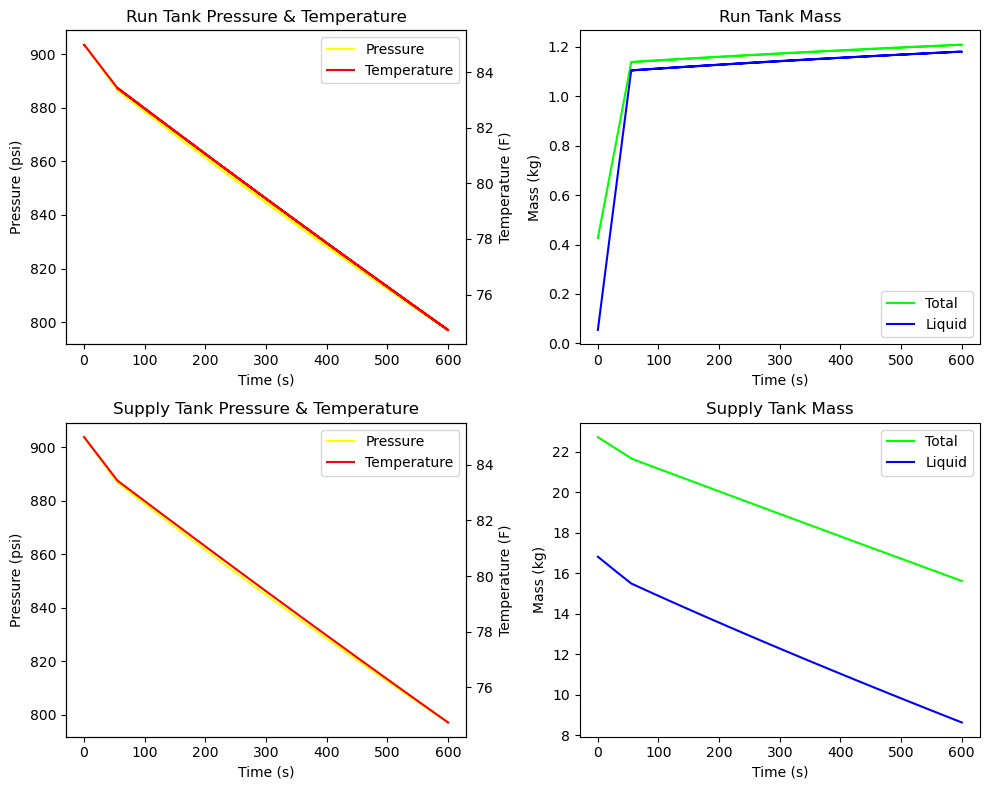

In [5]:
# Plotting
run_df = pd.DataFrame(run_tank.data)
run_df['Pressure'] = Tank.Pa_to_psi(run_df['Pressure'])
run_df['Temperature'] = Tank.k_to_f(run_df['Temperature'])

supply_df = pd.DataFrame(supply_tank.data)
supply_df['Pressure'] = Tank.Pa_to_psi(supply_df['Pressure'])
supply_df['Temperature'] = Tank.k_to_f(supply_df['Temperature'])

dataframes = [run_df, supply_df]
num_plots = 2
fig, axs = plt.subplots(nrows=len(dataframes), ncols=num_plots, figsize=(5*num_plots,4*len(dataframes)))

for i in range(len(dataframes)):
    ax1 = axs[i,0]
    # Pressure and Temperature on the same plot with twin y-axes
    lineP = ax1.plot(dataframes[i].Time, dataframes[i].Pressure, label='Pressure', color='yellow', linestyle='-')
    axtwin = ax1.twinx()
    lineT = axtwin.plot(dataframes[i].Time, dataframes[i].Temperature, label='Temperature', color='red', linestyle='-')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Pressure (psi)')
    axtwin.set_ylabel('Temperature (F)')
    ax1.set_title(tanks[i].name + ' Pressure & Temperature')
    lines = lineP + lineT
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    # Mass plot
    ax2 = axs[i,1]
    ax2.plot(dataframes[i].Time, dataframes[i].Mass, label='Total', color='lime', linestyle='-')
    ax2.plot(dataframes[i].Time, dataframes[i].Liquid, label='Liquid', color='blue', linestyle='-')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Mass (kg)')
    ax2.set_title(tanks[i].name + ' Mass')
    ax2.legend()

    # Energy plot
    # ax3.plot(dataframes[i].Time, dataframes[i].Energy, label='Energy', color='purple', linestyle='-')
    # ax3.set_xlabel('Time (s)')
    # ax3.set_ylabel('Energy (J)')
    # ax3.set_title('Energy')
    # ax3.legend()

    # Mass Flow Breakdown plot
    # ax3 = axs[i,2]
    # ax3.plot(dataframes[i].Time, dataframes[i]['Vapor Flow In'], label='Vapor Flow In', color='orange', linestyle='-')
    # ax3.plot(dataframes[i].Time, dataframes[i]['Liquid Flow In'], label='Liquid Flow In', color='blue', linestyle='-')
    # ax3.plot(dataframes[i].Time, dataframes[i]['Vapor Flow Out'], label='Vapor Flow Out', color='red', linestyle='-')
    # ax3.plot(dataframes[i].Time, dataframes[i]['Liquid Flow Out'], label='Liquid Flow Out', color='green', linestyle='-')
    # ax3.set_xlabel('Time (s)')
    # ax3.set_ylabel('Mass Flow (kg/s)')
    # ax3.set_title(tanks[i].name + ' Mass Flow Breakdown')
    # ax3.legend()

plt.tight_layout()
#plt.savefig('mass_runout.png')
plt.show()